# Customer Churn Prediction — Complete Notebook
A simple notebook-first version of the project.

In [9]:
import sqlite3, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'folder2' else Path.cwd()
DATA = ROOT / 'data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(DATA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df['tenure_group'] = pd.cut(df['tenure'], [-1,5,11,23,47,999], labels=['0-5','6-11','12-23','24-47','48+'])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-5
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,24-47
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-5
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-47
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-5


## 1. Data validation and SQL

In [10]:
print('Rows, columns:', df.shape)
print('Duplicates:', df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).head())
print(f'Observed churn rate: {df.Churn.mean():.2%}')
db = sqlite3.connect(ROOT / 'database/churn_notebook.db')
df.to_sql('customers', db, if_exists='replace', index=False)
sql = '''SELECT Contract, COUNT(*) customers, SUM(Churn) churned, ROUND(100.0*AVG(Churn),2) churn_rate_pct FROM customers GROUP BY Contract ORDER BY churn_rate_pct DESC'''
pd.read_sql_query(sql, db)

Rows, columns: (7043, 22)
Duplicates: 0


TotalCharges      11
customerID         0
gender             0
Churn              0
MonthlyCharges     0
dtype: int64

Observed churn rate: 26.54%


,Contract,customers,churned,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [11]:
queries = {
 'overall': 'SELECT COUNT(*) customers, SUM(Churn) churned, ROUND(100.0*AVG(Churn),2) churn_rate_pct FROM customers',
 'payment': 'SELECT PaymentMethod, COUNT(*) customers, ROUND(100.0*AVG(Churn),2) churn_rate_pct FROM customers GROUP BY PaymentMethod ORDER BY churn_rate_pct DESC',
 'tenure': "SELECT tenure_group, COUNT(*) customers, ROUND(100.0*AVG(Churn),2) churn_rate_pct FROM customers GROUP BY tenure_group"
}
for name, query in queries.items():
    print(name); display(pd.read_sql_query(query, db))

overall


,customers,churned,churn_rate_pct
0,7043,1869,26.54


payment


,PaymentMethod,customers,churn_rate_pct
0,Electronic check,2365,45.29
1,Mailed check,1612,19.11
2,Bank transfer (automatic),1544,16.71
3,Credit card (automatic),1522,15.24


tenure


,tenure_group,customers,churn_rate_pct
0,0-5,1371,54.27
1,12-23,1047,29.51
2,24-47,1624,20.87
3,48+,2303,9.64
4,6-11,698,36.53


## 2. EDA

,customers,churn_rate
Contract,,
Month-to-month,3875,0.427097
One year,1473,0.112695
Two year,1695,0.028319


,customers,churn_rate
PaymentMethod,,
Electronic check,2365,0.452854
Mailed check,1612,0.191067
Bank transfer (automatic),1544,0.167098
Credit card (automatic),1522,0.152431


,customers,churn_rate
tenure_group,,
0-5,1371,0.542670
6-11,698,0.365330
12-23,1047,0.295129
24-47,1624,0.208744
48+,2303,0.096396


,customers,churn_rate
InternetService,,
Fiber optic,3096,0.418928
DSL,2421,0.189591
No,1526,0.074050


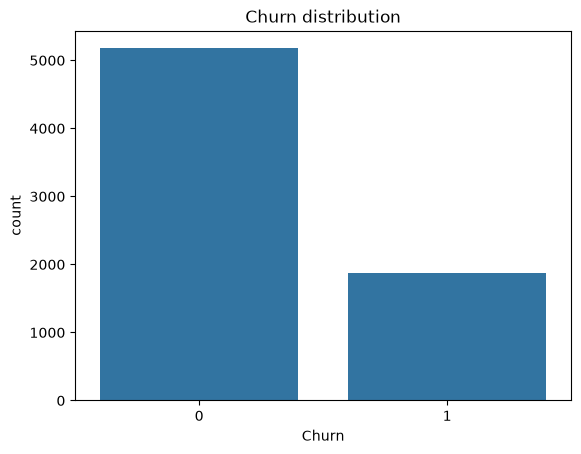

In [12]:
for col in ['Contract','PaymentMethod','tenure_group','InternetService']:
    summary = df.groupby(col, observed=False)['Churn'].agg(['count','mean']).sort_values('mean', ascending=False)
    display(summary.rename(columns={'count':'customers','mean':'churn_rate'}))
sns.countplot(data=df, x='Churn'); plt.title('Churn distribution'); plt.show()

## 3. Preprocessing and five independent models

In [13]:
X = df.drop(columns=['Churn','customerID','tenure_group']); y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,stratify=y,random_state=42)
num = X_train.select_dtypes(include='number').columns; cat = X_train.select_dtypes(exclude='number').columns
pre = ColumnTransformer([('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num),('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('encode',OneHotEncoder(handle_unknown='ignore'))]),cat)])
cv = StratifiedKFold(5,shuffle=True,random_state=42)
models = {
 'Dummy': (DummyClassifier(strategy='most_frequent'), {}),
 'Logistic Regression': (LogisticRegression(max_iter=1500,class_weight='balanced',l1_ratio=0), {'model__C':[.1,1,10]}),
 'Decision Tree': (DecisionTreeClassifier(class_weight='balanced',random_state=42), {'model__max_depth':[4,8,None],'model__min_samples_leaf':[1,3]}),
 'Random Forest': (RandomForestClassifier(class_weight='balanced',random_state=42,n_jobs=-1), {'model__n_estimators':[150,300],'model__max_depth':[8,None],'model__max_features':['sqrt']}),
}
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = (XGBClassifier(eval_metric='logloss',tree_method='hist',random_state=42,n_jobs=-1), {'model__n_estimators':[150,300],'model__max_depth':[3,6],'model__learning_rate':[.05,.1],'model__subsample':[.8],'model__colsample_bytree':[.8]})
except Exception as e:
    print('XGBoost unavailable:', e)

In [14]:
results, fitted = {}, {}
for name,(estimator,grid) in models.items():
    pipe = Pipeline([('preprocessing',pre),('model',estimator)])
    fitted_model = GridSearchCV(pipe,grid,scoring='roc_auc',cv=cv,n_jobs=-1) if grid else pipe
    fitted_model.fit(X_train,y_train); fitted[name] = fitted_model
    prob = fitted_model.predict_proba(X_test)[:,1]; pred = (prob>=.5).astype(int)
    results[name] = {'Accuracy':accuracy_score(y_test,pred),'Precision':precision_score(y_test,pred,zero_division=0),'Recall':recall_score(y_test,pred),'F1':f1_score(y_test,pred),'ROC-AUC':roc_auc_score(y_test,prob),'Confusion Matrix':confusion_matrix(y_test,pred).tolist()}
comparison = pd.DataFrame(results).T
display((comparison[['Accuracy','Precision','Recall','F1','ROC-AUC']]*100).round(2))

,Accuracy,Precision,Recall,F1,ROC-AUC
Dummy,73.456352,0.0,0.0,0.0,50.0
Logistic Regression,73.953158,50.604491,78.342246,61.490031,84.054354
Decision Tree,73.456352,50.0,82.085561,62.145749,83.456819
Random Forest,75.443577,52.491103,78.877005,63.034188,84.210907
XGBoost,80.908446,67.918089,53.208556,59.670165,84.854168


In [15]:
best_name = comparison.drop(index='Dummy')['ROC-AUC'].idxmax()
final_model = fitted[best_name]
print('Selected model:', best_name)
print('Selection rule: highest held-out ROC-AUC after training-only CV tuning; F1 breaks ties.')
import joblib
joblib.dump(final_model, ROOT/'models/notebook_final_model.joblib')
print('Saved models/notebook_final_model.joblib')

Selected model: XGBoost
Selection rule: highest held-out ROC-AUC after training-only CV tuning; F1 breaks ties.
Saved models/notebook_final_model.joblib


## 4. Prediction

In [16]:
customer = X.iloc[[0]].copy()
probability = final_model.predict_proba(customer)[0,1]
risk = 'High' if probability >= .5 else ('Medium' if probability >= .3 else 'Low')
print({'churn_probability':round(float(probability),4),'predicted_class':int(probability>=.5),'risk':risk})

{'churn_probability': 0.6937, 'predicted_class': 1, 'risk': 'High'}


## 5. K-Means segmentation

Silhouette scores: {2: 0.4797310580369739, 3: 0.4513578650260217, 4: 0.47196708850827157, 5: 0.4435094539036533, 6: 0.4374630841455399} Selected k: 2


,customers,churn_rate,avg_tenure,avg_monthly_charges
cluster,,,,
0,4683,0.313901,20.027333,52.165706
1,2360,0.169068,56.865254,89.756186


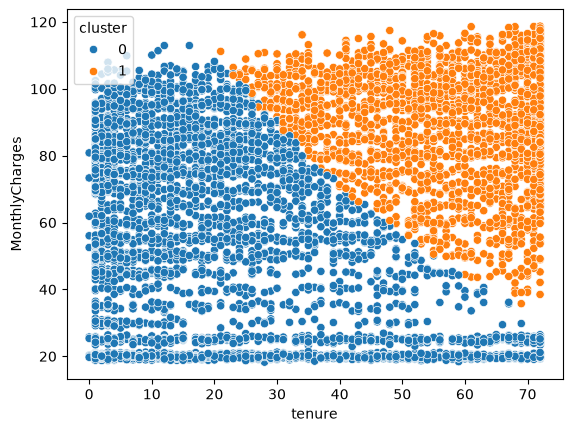

In [17]:
cluster_features = df[['tenure','MonthlyCharges','TotalCharges']].fillna(df[['tenure','MonthlyCharges','TotalCharges']].median())
scaled = StandardScaler().fit_transform(cluster_features)
scores = {}
for k in range(2,7):
    labels = KMeans(n_clusters=k,n_init=10,random_state=42).fit_predict(scaled)
    scores[k] = silhouette_score(scaled,labels)
best_k = max(scores,key=scores.get)
df['cluster'] = KMeans(n_clusters=best_k,n_init=10,random_state=42).fit_predict(scaled)
print('Silhouette scores:',scores,'Selected k:',best_k)
display(df.groupby('cluster').agg(customers=('cluster','size'),churn_rate=('Churn','mean'),avg_tenure=('tenure','mean'),avg_monthly_charges=('MonthlyCharges','mean')))
sns.scatterplot(data=df,x='tenure',y='MonthlyCharges',hue='cluster',palette='tab10'); plt.show()

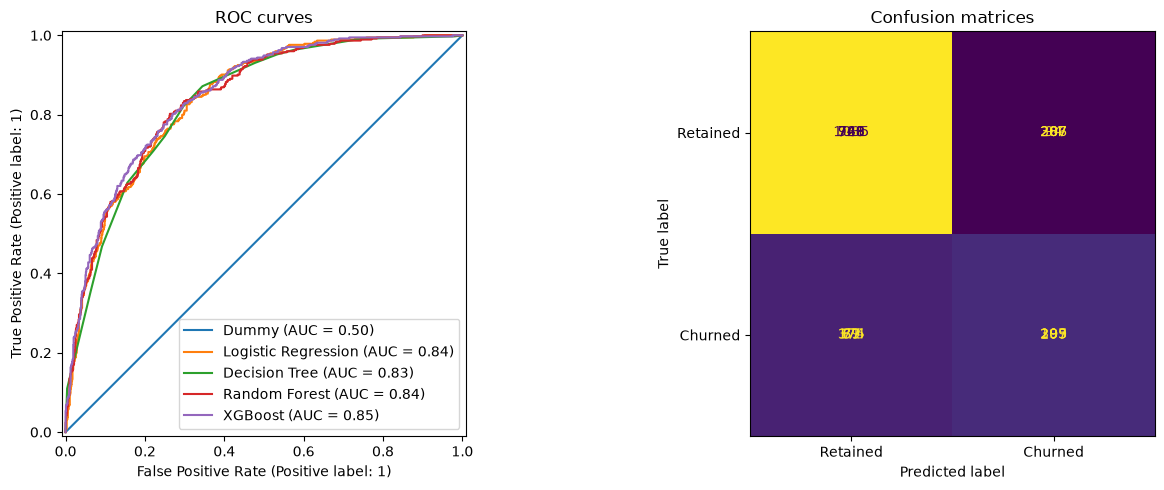

In [18]:
# Confusion matrices and ROC curves
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, fitted_model in fitted.items():
    prob = fitted_model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[0])
    ConfusionMatrixDisplay.from_predictions(y_test, (prob >= .5).astype(int), display_labels=['Retained','Churned'], ax=axes[1], colorbar=False)
axes[0].set_title('ROC curves')
axes[1].set_title('Confusion matrices')
plt.tight_layout()
plt.show()


,feature,importance
14,Contract,0.074107
4,tenure,0.058067
7,InternetService,0.011718
8,OnlineSecurity,0.005995
18,TotalCharges,0.005510
17,MonthlyCharges,0.003600
16,PaymentMethod,0.003375
11,TechSupport,0.002580
6,MultipleLines,0.002580
15,PaperlessBilling,0.002053


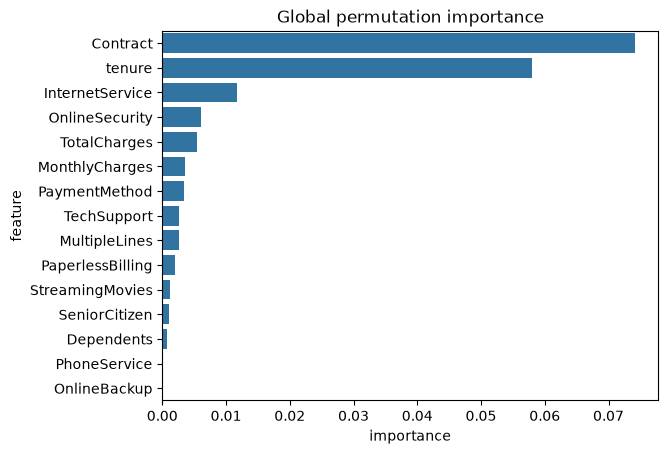

In [19]:
# Permutation feature importance for the selected complete pipeline
from sklearn.inspection import permutation_importance
importance = permutation_importance(final_model, X_test, y_test, scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=-1)
feature_importance = pd.DataFrame({'feature': X_test.columns, 'importance': importance.importances_mean}).sort_values('importance', ascending=False)
display(feature_importance.head(15))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Global permutation importance')
plt.show()


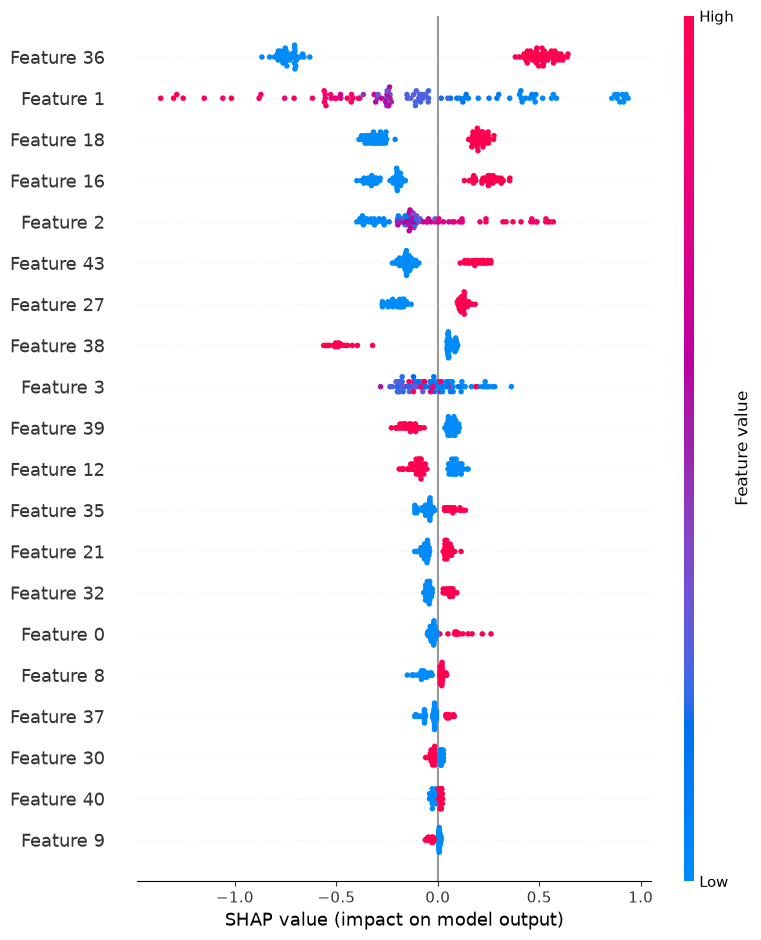

In [20]:
# Optional SHAP explanation; no values are fabricated if SHAP is unavailable
try:
    import shap
    fitted_pipe = final_model.best_estimator_ if hasattr(final_model, 'best_estimator_') else final_model
    transformed = fitted_pipe.named_steps['preprocessing'].transform(X_test.head(100))
    estimator = fitted_pipe.named_steps['model']
    shap_explainer = shap.TreeExplainer(estimator)
    shap_result = shap_explainer.shap_values(transformed)
    shap_values = shap_result[1] if isinstance(shap_result, list) else shap_result
    shap.summary_plot(shap_values, transformed, show=False)
    plt.tight_layout(); plt.show()
except Exception as error:
    print('SHAP is unavailable or incompatible; permutation importance above is the fallback.')
    print(error)


In [ ]:
# Confusion matrices and ROC curves
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, fitted_model in fitted.items():
    prob = fitted_model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[0])
    ConfusionMatrixDisplay.from_predictions(y_test, (prob >= .5).astype(int), display_labels=['Retained','Churned'], ax=axes[1], colorbar=False)
axes[0].set_title('ROC curves')
axes[1].set_title('Confusion matrices')
plt.tight_layout()
plt.show()


In [ ]:
# Permutation feature importance for the selected complete pipeline
from sklearn.inspection import permutation_importance
importance = permutation_importance(final_model, X_test, y_test, scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=-1)
feature_importance = pd.DataFrame({'feature': X_test.columns, 'importance': importance.importances_mean}).sort_values('importance', ascending=False)
display(feature_importance.head(15))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Global permutation importance')
plt.show()


In [ ]:
# Optional SHAP explanation; no values are fabricated if SHAP is unavailable
try:
    import shap
    fitted_pipe = final_model.best_estimator_ if hasattr(final_model, 'best_estimator_') else final_model
    transformed = fitted_pipe.named_steps['preprocessing'].transform(X_test.head(100))
    estimator = fitted_pipe.named_steps['model']
    shap_explainer = shap.TreeExplainer(estimator)
    shap_result = shap_explainer.shap_values(transformed)
    shap_values = shap_result[1] if isinstance(shap_result, list) else shap_result
    shap.summary_plot(shap_values, transformed, show=False)
    plt.tight_layout(); plt.show()
except Exception as error:
    print('SHAP is unavailable or incompatible; permutation importance above is the fallback.')
    print(error)
